In [3]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix

# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)



Path to dataset files: /home/samuele/.cache/kagglehub/datasets/shauryasrivastava01/liver-patient-dataset/versions/1


In [5]:
path = "Datasets/liver_patient_dataset.csv"
df = pd.read_csv(path)

In [6]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [7]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


### Distribuzione della classe Selector (il target)

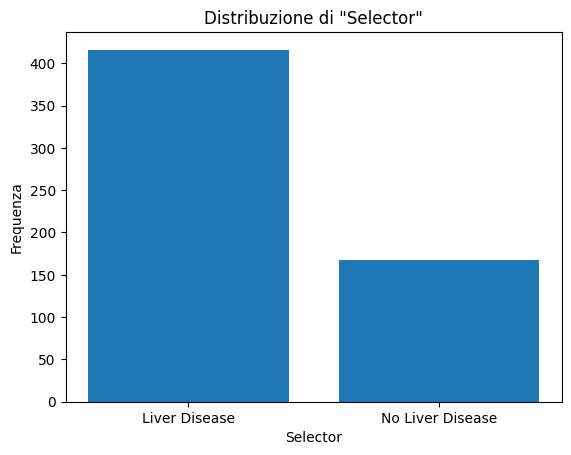

In [8]:
conteggi = df["Selector"].value_counts()

plt.bar(conteggi.index, conteggi.values)
plt.xlabel("Selector")
plt.ylabel("Frequenza")
plt.title('Distribuzione di "Selector"')
plt.show()

### Creazione trainining e testing set

In [9]:
feature_names = set(df.columns) - set(["Selector"])

target_name = "Selector"

categorical_features = set(["Gender"])
continuos_features = feature_names - set(["Gender"])

print(categorical_features)
print(continuos_features)
feature_names = list(feature_names)

{'Gender'}
{'ALB', 'TB', 'TP', 'Sgpt', 'Age', 'A/G Ratio', 'Alkphos', 'Sgot', 'DB'}


In [10]:
df_encoded = df.copy()

df_encoded["Gender"] = df_encoded["Gender"].astype("category").cat.codes
df_encoded["Selector"] = df_encoded["Selector"].astype("category").cat.codes

In [11]:
df_encoded

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,1
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,0
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,0
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,0


In [12]:
df_encoded["Selector"].dtype

dtype('int8')

In [13]:
df_encoded["Gender"].dtype

dtype('int8')

### addestriamo Il decisione Tree

In [14]:
y = df_encoded["Selector"]
#X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [15]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0


In [16]:
X_train.head()

,ALB,TB,TP,Sgpt,Age,A/G Ratio,Alkphos,Sgot,Gender,DB
401,1.6,7.3,6.8,44,50,0.30,92,236,1,3.7
395,3.2,0.8,6.3,24,45,1.00,140,20,1,0.2
3,3.4,1.0,6.8,14,58,1.00,182,20,1,0.4
102,4.2,0.9,6.9,36,17,1.55,224,45,1,0.2
175,4.0,0.8,7.3,43,31,1.20,198,31,1,0.2


In [17]:
y_train.head()

401    0
395    1
3      0
102    0
175    0
Name: Selector, dtype: int8

In [18]:

model = DecisionTreeClassifier(random_state=42)
model = model.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

In [19]:
# [
#     true 0, false 1
#     false 0, true 1
#  ]

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[91 34]
 [29 21]]

Accuracy: 0.64


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.73      0.76      0.74       120
           1       0.42      0.38      0.40        55

    accuracy                           0.64       175
   macro avg       0.57      0.57      0.57       175
weighted avg       0.63      0.64      0.64       175



### Miglioriamo l'albero

In [21]:
prunedModel = DecisionTreeClassifier(random_state=42,max_depth=5, min_samples_split=2)
prunedModel = prunedModel.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(prunedModel, filled=True, ax=ax)
plt.plot()

[]

In [22]:
y_pred = prunedModel.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[104  21]
 [ 41   9]]

Accuracy: 0.6457142857142857


In [23]:
#precision: Tra tutti quelli che il modello ha predetto come positivi, quanti erano davvero positivi?
#recall: Tra tutti quelli che erano davvero positivi, quanti ne ha trovati il modello?

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       145
           1       0.18      0.30      0.23        30

    accuracy                           0.65       175
   macro avg       0.51      0.51      0.50       175
weighted avg       0.72      0.65      0.68       175



### L'albero ha una bassa accuratezza, Usiamo il parametro di complessità

In [25]:
path = model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00204248 0.00204248 0.00210084 0.00222816 0.00222816
 0.00224673 0.00226244 0.00235486 0.00239398 0.00245098 0.0025531
 0.00326797 0.00367647 0.00367647 0.00371361 0.00420168 0.00420168
 0.00421713 0.00425099 0.0043573  0.00441176 0.00446429 0.0045098
 0.00465686 0.00485098 0.00499076 0.00526823 0.00597672 0.00640779
 0.00661765 0.00670041 0.0070028  0.00719375 0.00784032 0.00808945
 0.00837527 0.00932351 0.01163107 0.01228434 0.0142603  0.04182286]


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

results = []
#andare oltre 8 lo manda comunque in overfitting

for depth in range(4, 8):
    for complexity in ccp_alphas:
        clf = DecisionTreeClassifier(
            max_depth=depth,
            ccp_alpha=complexity,
            class_weight="balanced",
            random_state=42
        )

        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        results.append({
            "max_depth": depth,
            "ccp_alpha": complexity,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

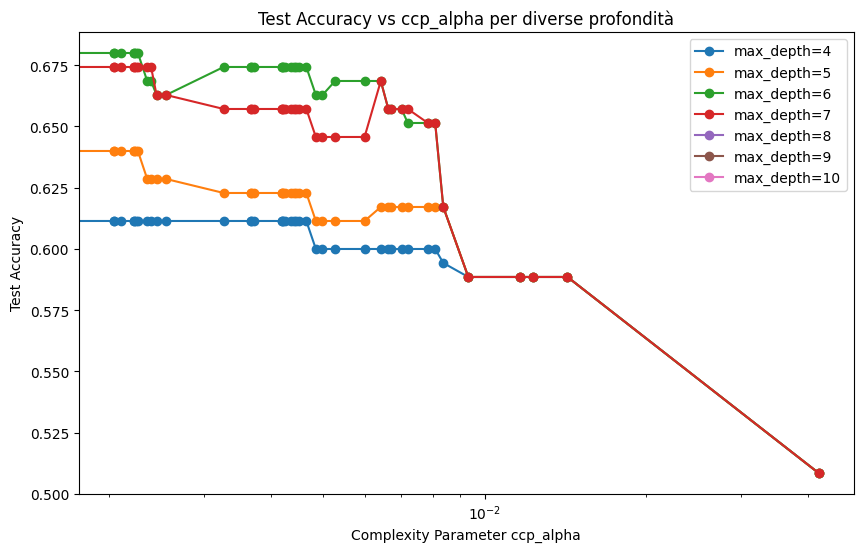

In [27]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    test_acc = [r["test_accuracy"] for r in depth_results]

    plt.plot(alphas, test_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [28]:
best_result = max(results, key=lambda x: x["test_accuracy"])

print("Miglior max_depth:", best_result["max_depth"])
print("Miglior ccp_alpha:", best_result["ccp_alpha"])
print("Train accuracy:", best_result["train_accuracy"])
print("Test accuracy:", best_result["test_accuracy"])

Miglior max_depth: 6
Miglior ccp_alpha: 0.0
Train accuracy: 0.7745098039215687
Test accuracy: 0.68


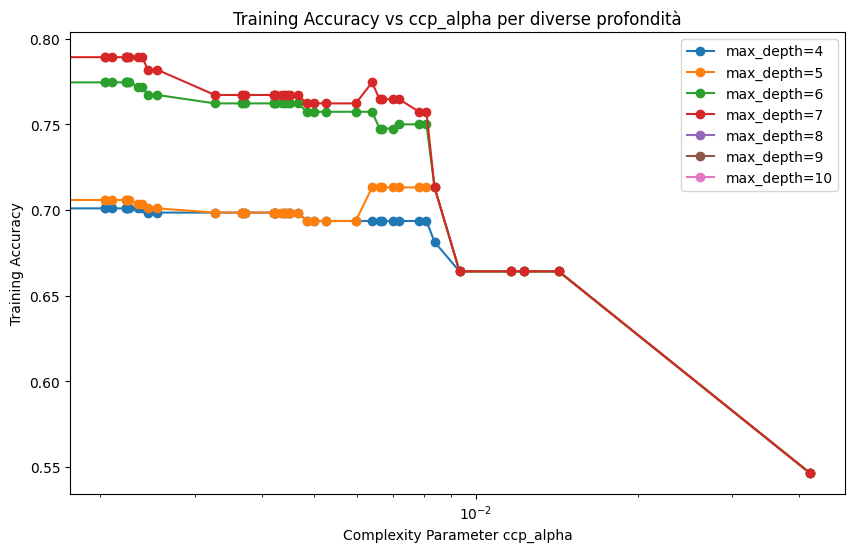

In [29]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    train_acc = [r["train_accuracy"] for r in depth_results]

    plt.plot(alphas, train_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [30]:
best_clf = DecisionTreeClassifier(
    max_depth=best_result["max_depth"],
    ccp_alpha=best_result["ccp_alpha"],
    class_weight="balanced",
    random_state=42
)

best_clf.fit(X_train, y_train)

print("Accuracy train:", best_clf.score(X_train, y_train))
print("Accuracy test:", best_clf.score(X_test, y_test))

Accuracy train: 0.7745098039215687
Accuracy test: 0.68


In [31]:
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[77 48]
 [ 8 42]]

Accuracy: 0.68


In [32]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.62      0.91      0.73        85
           1       0.84      0.47      0.60        90

    accuracy                           0.68       175
   macro avg       0.73      0.69      0.67       175
weighted avg       0.73      0.68      0.66       175



### diamo un occhiata con la balancedPrecision

In [33]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.62      0.73       125
           1       0.47      0.84      0.60        50

    accuracy                           0.68       175
   macro avg       0.69      0.73      0.67       175
weighted avg       0.78      0.68      0.70       175

Balanced accuracy: 0.728
[[77 48]
 [ 8 42]]


### Andiamo a modificare l'addestramento per dare più peso ai dati minoritari

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try=None,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    pos_label=1,
    random_state=42,
    print_report=True
):
    """
    Addestra più DecisionTreeClassifier provando:
    - diverse profondità;
    - diversi valori di ccp_alpha;
    - diversi pesi manuali per le classi.

    Restituisce:
    - best_clf: modello migliore riaddestrato;
    - results_df: DataFrame con tutti i risultati;
    - best_row: riga del DataFrame corrispondente al miglior modello.
    """

    if weights_to_try is None:
        weights_to_try = [
            {0: 1, 1: 1},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5},
            {0: 1, 1: 10}
        ]

    results = []

    for depth in depths:
        for complexity in ccp_alphas:
            for weights in weights_to_try:

                clf = DecisionTreeClassifier(
                    max_depth=depth,
                    ccp_alpha=complexity,
                    class_weight=weights,
                    random_state=random_state
                )

                clf.fit(X_train, y_train)

                y_pred_train = clf.predict(X_train)
                y_pred_test = clf.predict(X_test)

                train_acc = accuracy_score(y_train, y_pred_train)
                test_acc = accuracy_score(y_test, y_pred_test)

                train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
                test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

                precision_1 = precision_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                recall_1 = recall_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                f1_1 = f1_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="weighted",
                    zero_division=0
                )

                results.append({
                    "max_depth": depth,
                    "ccp_alpha": complexity,
                    "class_weight": weights,
                    "weight_0": weights.get(0, np.nan),
                    "weight_1": weights.get(1, np.nan),

                    "train_accuracy": train_acc,
                    "test_accuracy": test_acc,

                    "train_balanced_accuracy": train_bal_acc,
                    "test_balanced_accuracy": test_bal_acc,

                    "precision_class_1": precision_1,
                    "recall_class_1": recall_1,
                    "f1_class_1": f1_1,

                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                })

    results_df = pd.DataFrame(results)

    if scoring_metric not in results_df.columns:
        raise ValueError(
            f"scoring_metric non valido: {scoring_metric}. "
            f"Scegli tra: {list(results_df.columns)}"
        )

    best_index = results_df[scoring_metric].idxmax()
    best_row = results_df.loc[best_index]

    best_clf = DecisionTreeClassifier(
        max_depth=int(best_row["max_depth"]),
        ccp_alpha=best_row["ccp_alpha"],
        class_weight=best_row["class_weight"],
        random_state=random_state
    )

    best_clf.fit(X_train, y_train)

    y_pred_best = best_clf.predict(X_test)

    if print_report:
        print("Migliore configurazione trovata:")
        print(best_row)

        print("\nConfusion matrix:")
        print(confusion_matrix(y_test, y_pred_best))

        print("\nClassification report:")
        print(classification_report(y_test, y_pred_best, zero_division=0))

    return best_clf, results_df, best_row

In [35]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 4.5},
    {0: 1, 1: 5},
    {0: 1, 1: 7},
    {0: 1, 1: 9},
    {0: 1, 1: 10}
]

best_clf, results_df, best_row = train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1"
)


Migliore configurazione trovata:
max_depth                             7
ccp_alpha                           0.0
class_weight               {0: 1, 1: 4}
weight_0                              1
weight_1                            4.0
train_accuracy                 0.776961
test_accuracy                  0.691429
train_balanced_accuracy        0.843643
test_balanced_accuracy            0.736
precision_class_1              0.477273
recall_class_1                     0.84
f1_class_1                     0.608696
macro_f1                       0.676989
weighted_f1                    0.706258
Name: 1391, dtype: object

Confusion matrix:
[[79 46]
 [ 8 42]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.63      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.69       175
   macro avg       0.69      0.74      0.68       175
weighted avg       0.78      0.69      0.71    

In [36]:
y_pred_test = best_clf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.91      0.63      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.69       175
   macro avg       0.69      0.74      0.68       175
weighted avg       0.78      0.69      0.71       175



### Facciamo un ensemble a majority

In [37]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [38]:
def majority_vote(predictions):
    """
    predictions deve essere una lista con 3 array.

    Esempio:
    predictions = [
        predizioni_modello_1,
        predizioni_modello_2,
        predizioni_modello_3
    ]

    Ogni array contiene valori 0/1.
    """

    final_predictions = []

    n_samples = len(predictions[0])

    for i in range(n_samples):
        votes_for_1 = 0

        for model_predictions in predictions:
            if model_predictions[i] == 1:
                votes_for_1 = votes_for_1 + 1

        if votes_for_1 >= 2:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


def train_three_trees(
    X_train,
    y_train,
    max_depth,
    ccp_alpha,
    class_weight,
    random_state=42
):
    models = []

    splitter = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=random_state
    )

    fold_number = 0

    for train_index, part_index in splitter.split(X_train, y_train):
        X_part = X_train.iloc[part_index]
        y_part = y_train.iloc[part_index]

        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            class_weight=class_weight,
            random_state=random_state + fold_number
        )

        tree.fit(X_part, y_part)

        models.append(tree)

        fold_number = fold_number + 1

    return models
def predict_ensemble(models, X_test):
    predictions = []

    for model in models:
        model_predictions = model.predict(X_test)
        predictions.append(model_predictions)

    final_predictions = majority_vote(predictions)

    return final_predictions

def search_best_ensemble_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_models = None
    best_score = -1
    best_row = None
    best_predictions = None

    for depth in depths:

        for alpha in ccp_alphas:

            for weights in weights_to_try:

                models = train_three_trees(
                    X_train=X_train,
                    y_train=y_train,
                    max_depth=depth,
                    ccp_alpha=alpha,
                    class_weight=weights,
                    random_state=random_state
                )

                y_pred = predict_ensemble(
                    models=models,
                    X_test=X_test
                )

                test_accuracy = accuracy_score(y_test, y_pred)

                test_balanced_accuracy = balanced_accuracy_score(
                    y_test,
                    y_pred
                )

                precision_class_1 = precision_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                recall_class_1 = recall_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                f1_class_1 = f1_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )

                row = {
                    "max_depth": depth,
                    "ccp_alpha": alpha,
                    "class_weight": weights,
                    "weight_0": weights[0],
                    "weight_1": weights[1],
                    "test_accuracy": test_accuracy,
                    "test_balanced_accuracy": test_balanced_accuracy,
                    "precision_class_1": precision_class_1,
                    "recall_class_1": recall_class_1,
                    "f1_class_1": f1_class_1,
                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_models = models
                    best_row = row
                    best_predictions = y_pred

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    print("Metrica usata per scegliere:", scoring_metric)
    print("Valore migliore:", best_score)

    return best_models, results_df, best_row, best_predictions


In [39]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.011631065783534442), 'class_weight': {0: 1, 1: 5}, 'weight_0': 1, 'weight_1': 5, 'test_accuracy': 0.6114285714285714, 'test_balanced_accuracy': 0.704, 'precision_class_1': 0.41818181818181815, 'recall_class_1': 0.92, 'f1_class_1': 0.575, 'macro_f1': 0.6085526315789473, 'weighted_f1': 0.6229323308270677}

Confusion matrix:
[[61 64]
 [ 4 46]]

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.49      0.64       125
           1       0.42      0.92      0.57        50

    accuracy                           0.61       175
   macro avg       0.68      0.70      0.61       175
weighted avg       0.79      0.61      0.62       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.575


In [40]:
results_df.sort_values(
    by="f1_class_1",
    ascending=False
).head(10)

,max_depth,ccp_alpha,class_weight,weight_0,weight_1,test_accuracy,test_balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,macro_f1,weighted_f1
566,5,0.011631,"{0: 1, 1: 5}",1,5.0,0.611429,0.704,0.418182,0.92,0.575000,0.608553,0.622932
580,5,0.014260,"{0: 1, 1: 5}",1,5.0,0.611429,0.704,0.418182,0.92,0.575000,0.608553,0.622932
573,5,0.012284,"{0: 1, 1: 5}",1,5.0,0.611429,0.704,0.418182,0.92,0.575000,0.608553,0.622932
496,5,0.005977,"{0: 1, 1: 5}",1,5.0,0.605714,0.700,0.414414,0.92,0.571429,0.603175,0.616780
468,5,0.004657,"{0: 1, 1: 5}",1,5.0,0.605714,0.700,0.414414,0.92,0.571429,0.603175,0.616780
461,5,0.004510,"{0: 1, 1: 5}",1,5.0,0.605714,0.700,0.414414,0.92,0.571429,0.603175,0.616780
482,5,0.004991,"{0: 1, 1: 5}",1,5.0,0.605714,0.700,0.414414,0.92,0.571429,0.603175,0.616780
475,5,0.004851,"{0: 1, 1: 5}",1,5.0,0.605714,0.700,0.414414,0.92,0.571429,0.603175,0.616780
426,5,0.004217,"{0: 1, 1: 5}",1,5.0,0.605714,0.700,0.414414,0.92,0.571429,0.603175,0.616780
454,5,0.004464,"{0: 1, 1: 5}",1,5.0,0.605714,0.700,0.414414,0.92,0.571429,0.603175,0.616780


In [41]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.94      0.49      0.64       125
           1       0.42      0.92      0.57        50

    accuracy                           0.61       175
   macro avg       0.68      0.70      0.61       175
weighted avg       0.79      0.61      0.62       175



### proviamo  a fare undersampling del dataframe

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split


def train_test_split_with_undersampling(
    df,
    target_col,
    test_size=0.3,
    random_state=42,
    stratify=False
):
    """
    Divide il DataFrame in train/test e applica undersampling solo al training set.

    Parametri:
    - df: DataFrame completo
    - target_col: nome della colonna target, esempio "Selector"
    - test_size: percentuale del test set
    - random_state: seed per riproducibilità
    - stratify: se True, mantiene proporzioni simili delle classi nello split

    Ritorna:
    - X_train_under
    - X_test
    - y_train_under
    - y_test
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    if stratify:
        stratify_values = y
    else:
        stratify_values = None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_values
    )

    train_df = X_train.copy()
    train_df[target_col] = y_train

    class_counts = train_df[target_col].value_counts()
    min_class_count = class_counts.min()

    undersampled_parts = []

    for class_value in class_counts.index:
        class_df = train_df[train_df[target_col] == class_value]

        class_df_under = class_df.sample(
            n=min_class_count,
            random_state=random_state
        )

        undersampled_parts.append(class_df_under)

    train_df_under = pd.concat(undersampled_parts)

    train_df_under = train_df_under.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    X_train_under = train_df_under.drop(columns=[target_col])
    y_train_under = train_df_under[target_col]

    return X_train_under, X_test, y_train_under, y_test

In [43]:
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df=df_encoded,
    target_col="Selector",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [44]:
y_train.value_counts()

Selector
0    120
1    120
Name: count, dtype: int64

In [45]:
X_test.count()

Age          175
Gender       175
TB           175
DB           175
Alkphos      175
Sgpt         175
Sgot         175
TP           175
ALB          175
A/G Ratio    175
dtype: int64

In [46]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1.5}, 'weight_0': 1, 'weight_1': 1.5, 'test_accuracy': 0.6914285714285714, 'test_balanced_accuracy': 0.7755984042553192, 'precision_class_1': 0.4639175257731959, 'recall_class_1': 0.9574468085106383, 'f1_class_1': 0.625, 'macro_f1': 0.6814320388349515, 'weighted_f1': 0.7075520110957004}

Confusion matrix:
[[76 52]
 [ 2 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.59      0.74       128
           1       0.46      0.96      0.62        47

    accuracy                           0.69       175
   macro avg       0.72      0.78      0.68       175
weighted avg       0.84      0.69      0.71       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.625


In [47]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      0.59      0.74       128
           1       0.46      0.96      0.62        47

    accuracy                           0.69       175
   macro avg       0.72      0.78      0.68       175
weighted avg       0.84      0.69      0.71       175



### Usiamo le random forests

In [48]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def search_best_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators_to_try,
    depths_to_try,
    weights_to_try,
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_model = None
    best_score = -1
    best_row = None
    best_predictions = None

    for n_estimators in n_estimators_to_try:
        for max_depth in depths_to_try:
            for weights in weights_to_try:

                rf = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    class_weight=weights,
                    random_state=random_state,
                    n_jobs=-1
                )

                rf.fit(X_train, y_train)

                y_pred_train = rf.predict(X_train)
                y_pred_test = rf.predict(X_test)

                row = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "class_weight": weights,
                    "weight_0": weights[0] if isinstance(weights, dict) else None,
                    "weight_1": weights[1] if isinstance(weights, dict) else None,

                    "train_accuracy": accuracy_score(y_train, y_pred_train),
                    "test_accuracy": accuracy_score(y_test, y_pred_test),
                    "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),

                    "precision_class_1": precision_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "recall_class_1": recall_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "f1_class_1": f1_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "macro_f1": f1_score(
                        y_test,
                        y_pred_test,
                        average="macro",
                        zero_division=0
                    )
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_model = rf
                    best_row = row
                    best_predictions = y_pred_test

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    return best_model, results_df, best_row, best_predictions

In [ ]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators_to_try=n_estimators_to_try,
    depths_to_try=depths_to_try,
    weights_to_try=weights_to_try,
    scoring_metric="macro_f1"
)

In [ ]:
best_rf.fit(X_train, y_train)

y_pred_test = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.89      0.65      0.75       128
           1       0.45      0.79      0.57        47

    accuracy                           0.69       175
   macro avg       0.67      0.72      0.66       175
weighted avg       0.77      0.69      0.70       175



In [ ]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators_to_try=n_estimators_to_try,
    depths_to_try=depths_to_try,
    weights_to_try=weights_to_try,
    scoring_metric="macro_f1"
)

Migliore configurazione trovata:
{'n_estimators': 200, 'max_depth': None, 'class_weight': {0: 1, 1: 1}, 'weight_0': 1, 'weight_1': 1, 'train_accuracy': 1.0, 'test_accuracy': 0.6857142857142857, 'test_balanced_accuracy': 0.7178357712765957, 'precision_class_1': 0.45121951219512196, 'recall_class_1': 0.7872340425531915, 'f1_class_1': 0.5736434108527132, 'macro_f1': 0.6623873162860852}

Confusion matrix:
[[83 45]
 [10 37]]

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.65      0.75       128
           1       0.45      0.79      0.57        47

    accuracy                           0.69       175
   macro avg       0.67      0.72      0.66       175
weighted avg       0.77      0.69      0.70       175



### Sporchiamo Il Dataset

In [ ]:
# funzione per sporcare variabili categoriche
def corrupt_rows_cat(df, col, frac=0.1, random_state=None):
    #conto il numero di colonne che devo rovinare

    
    corrupt_df = df.copy()

    if random_state != None: random_state = None

    #recupero i valori univoci
    unique_values = corrupt_df[col].unique()

    # Controllo di sicurezza: se ho un solo valore possibile, non posso fare la sostituzione
    if len(unique_values) <= 1:
        print(f"Attenzione: la colonna '{col}' ha un solo valore unico. Nessuna modifica applicata.")
        return corrupt_df
    
    n_rows_to_corrupt = int(frac * len(corrupt_df[col]))

    indices_to_corrupt = np.random.choice(corrupt_df.index, size=n_rows_to_corrupt, replace=False)

    for idx in indices_to_corrupt:
        current_value = corrupt_df.at[idx, col]
        pool_of_new_value = unique_values[unique_values != current_value]
        corrupt_df.at[idx, col] = np.random.choice(pool_of_new_value)
    return corrupt_df

    #scelgo righe a caso
    #per scegliere righe a caso vado a indici:
        #creo un vettore degli indici (total_rows) lungo quando il df
        #faccio un ciclo lungo n_rows_to_corrupt
        #a ogni iterazione prendo una riga scelta a caso da total_rows e la metto nel vettore "rows_to_ruin"
        #elimino quella riga dal vettore total_row

#funzione per sporcare le variabili continue


### mostro le variabili dalla più importante alla meno importante

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# separo feature e target
X = df_encoded.drop(columns=["Selector"])
y = df_encoded["Selector"]

# scrivi qui le colonne categoriche
categoriche = ["gender"]

# True per le categoriche, False per le continue
discrete_mask = []

for col in X.columns:
    if col in categoriche:
        discrete_mask.append(True)
    else:
        discrete_mask.append(False)

# calcolo mutual information
mi = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

# creo tabella ordinata
importanza_variabili = pd.DataFrame({
    "variabile": X.columns,
    "importanza": mi
})

importanza_variabili = importanza_variabili.sort_values(
    by="importanza",
    ascending=False
)

print(importanza_variabili)

   variabile  importanza
5       Sgpt    0.072161
6       Sgot    0.068853
0        Age    0.066943
2         TB    0.053878
3         DB    0.048560
4    Alkphos    0.028152
8        ALB    0.025456
9  A/G Ratio    0.018387
1     Gender    0.000000
7         TP    0.000000


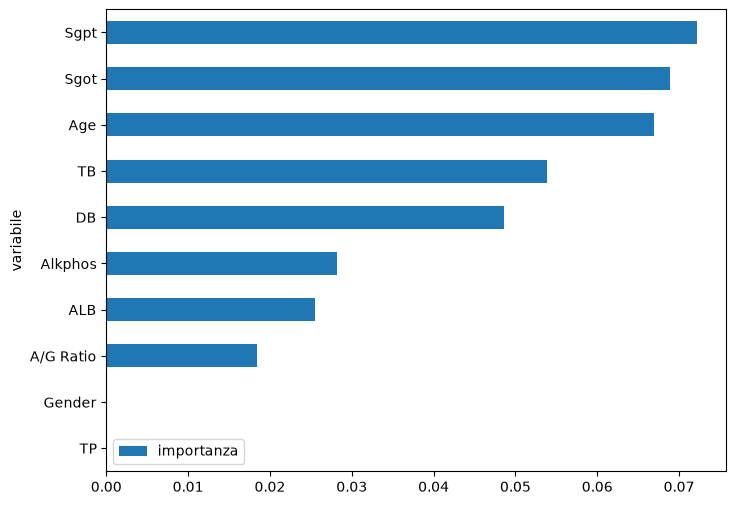

In [ ]:
import matplotlib.pyplot as plt

importanza_variabili.plot(
    kind="barh",
    x="variabile",
    y="importanza",
    figsize=(8, 6)
)

plt.gca().invert_yaxis()
plt.show()

### Proviamo a sporcare la feature SGPT in maniera progressiva mentre lo addestriamo e vediamo di quanto cala la performance del modello

In [ ]:
df_encoded.head

NameError: name 'df_encoded' is not defined